In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPooling2D
from tqdm import tqdm
import matplotlib.image as mpimg
import os
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install kagglehub

In [5]:
import os
from google.colab import files

print("Please upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

print("\nDownloading dataset from Kaggle...")
!kaggle datasets download -d paramaggarwal/fashion-product-images-small --unzip

print("\n✅ Download and extraction complete!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
 98% 554M/565M [00:01<00:00, 326MB/s]
100% 565M/565M [00:01<00:00, 431MB/s]

✅ Download and extraction complete!


In [6]:
df = pd.read_csv('styles.csv', on_bad_lines='skip')

In [46]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,53759.jpg


In [8]:
df['image'] = df['id'].astype(str) + '.jpg'

In [9]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [10]:
model = tf.keras.Sequential([
    base_model,
    GlobalMaxPooling2D()
])
print("✅ AI Model loaded successfully!")

✅ AI Model loaded successfully!


In [11]:
def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    expanded_img_array = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_input(expanded_img_array)

    result = model.predict(preprocessed_img, verbose=0)
    return result.flatten()

In [43]:
sample_size = len(df)
image_files = df['image'].tolist()[:sample_size]

In [44]:
feature_list = []
valid_image_names = []

In [45]:
print(f"\nExtracting mathematical features from {sample_size} images...")
for img_name in tqdm(image_files):
    img_path = os.path.join('/content/images', img_name)

    # Safety check: make sure the image file actually exists
    if os.path.exists(img_path):
        features = extract_features(img_path, model)
        feature_list.append(features)
        valid_image_names.append(img_name)


Extracting mathematical features from 44424 images...


100%|██████████| 44424/44424 [1:10:37<00:00, 10.48it/s]


In [47]:
feature_list = np.array(feature_list)
np.save('image_features_full.npy', feature_list)

In [48]:
np.save('image_names_full.npy', np.array(valid_image_names))

In [20]:
feature_list = np.load('image_features_500.npy')
filenames = np.load('image_names_500.npy')

In [36]:
query_index = 279
query_vector = feature_list[query_index].reshape(1, -1)
query_filename = filenames[query_index]

In [37]:
similarity_scores = cosine_similarity(query_vector, feature_list)[0]

In [38]:
top_5_indices = np.argsort(similarity_scores)[::-1][1:6]

Searching for matches similar to: 14869.jpg



(np.float64(-0.5), np.float64(59.5), np.float64(79.5), np.float64(-0.5))

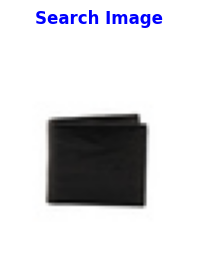

In [39]:
print(f"Searching for matches similar to: {query_filename}\n")

plt.figure(figsize=(16, 5))

# Plot the query image on the far left
plt.subplot(1, 6, 1)
img = mpimg.imread(os.path.join('/content/images', query_filename))
plt.imshow(img)
plt.title("Search Image", fontweight="bold", color="blue")
plt.axis('off')

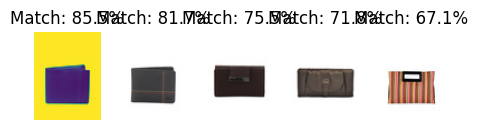

In [42]:
for i, match_idx in enumerate(top_5_indices):
    plt.subplot(1, 6, i + 2)
    match_filename = filenames[match_idx]

    img = mpimg.imread(os.path.join('/content/images', match_filename))
    plt.imshow(img)

    # Force strict rounding to 1 decimal place (e.g., 81.7%)
    match_score = similarity_scores[match_idx] * 100
    plt.title(f"Match: {match_score:.1f}%", fontsize=12)
    plt.axis('off')

plt.subplots_adjust(wspace=0.3)
plt.show()